In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

In [3]:
mi_test_pull_dict = pickle.load(open("./data/tmp/pull_by_hashes_mi_test.pkl", "rb"))
sr_stats_pull_dict = pickle.load(open("./data/tmp/pull_by_hashes_sr_stats.pkl", "rb"))
fvt_pull_dict = pickle.load(open("./data/tmp/pull_by_hashes_fvt.pkl", "rb"))

In [ ]:
for pull_dict in [sr_stats_pull_dict, 
                  mi_test_pull_dict, 
                  fvt_pull_dict
                  ]:
    for hash in pull_dict:
        hparams = TrainingInfo.load(hash).hparams
        is_step_4 = hparams["aux_info_step"] == 4
        if is_step_4:
            batch_size = hparams["dataloader"]["batch_size"]
            CR_fvt_hash = hparams["CR_fvt_hash"]
            hparams = TrainingInfo.load(CR_fvt_hash).hparams
        signal_ratio = hparams["dataset"]["signal_ratio"]
        SR_size = hparams["signal_region"]["4b_in_SR"]    
        
        for v in pull_dict[hash]:
            if is_step_4:
                v["batch_size"] = batch_size
            binning_mode = v["binning_mode"]
            nbins = v["nbins"]
            hists = v["hists"]
            hist_3b_rw = hists["3b_rw"]
            hist_3b_rw_sq = hists["3b_rw_sq"]
            hist_4b = hists["4b"]
            hist_4b_sq = hists["4b_sq"]
            var_o1 = hists["var_o1"]
            var_o2 = hists["var_o2"]
            hist_3b_o1 = hists["3b_corrected_o1"]
            hist_3b_o2 = hists["3b_corrected_o2"]
            hist_signal = hists["signal"]
            hist_bg4b = hists["bg4b"]
            
            if binning_mode == "train":
                var_o0 = hist_4b_sq + hist_3b_rw_sq
            else:
                var_o0 = hist_4b_sq + hist_3b_rw_sq / nbins**2

            v["signal_ratio"] = signal_ratio
            v["SR_size"] = SR_size
            v["pull_o0"] = (hist_4b - hist_3b_rw) / np.sqrt(var_o0)
            v["pull_o1"] = (hist_4b - hist_3b_o1) / np.sqrt(var_o1)
            v["pull_o2"] = (hist_4b - hist_3b_o2) / np.sqrt(var_o2)
            v["pull_signal"] = hist_signal / np.sqrt(var_o0)
            v["pull_bg4b"] = (hist_bg4b - hist_3b_rw) / np.sqrt(var_o0)

/tmp/ipykernel_3976603/4082703944.py:38: RuntimeWarning: invalid value encountered in divide
  v["pull_o0"] = (hist_4b - hist_3b_rw) / np.sqrt(var_o0)
/tmp/ipykernel_3976603/4082703944.py:39: RuntimeWarning: invalid value encountered in divide
  v["pull_o1"] = (hist_4b - hist_3b_o1) / np.sqrt(var_o1)
/tmp/ipykernel_3976603/4082703944.py:40: RuntimeWarning: invalid value encountered in divide
  v["pull_o2"] = (hist_4b - hist_3b_o2) / np.sqrt(var_o2)
/tmp/ipykernel_3976603/4082703944.py:41: RuntimeWarning: invalid value encountered in divide
  v["pull_signal"] = hist_signal / np.sqrt(var_o0)
/tmp/ipykernel_3976603/4082703944.py:42: RuntimeWarning: invalid value encountered in divide
  v["pull_bg4b"] = (hist_bg4b - hist_3b_rw) / np.sqrt(var_o0)


/tmp/ipykernel_3976603/4082703944.py:38: RuntimeWarning: divide by zero encountered in divide
  v["pull_o0"] = (hist_4b - hist_3b_rw) / np.sqrt(var_o0)
/tmp/ipykernel_3976603/4082703944.py:39: RuntimeWarning: divide by zero encountered in divide
  v["pull_o1"] = (hist_4b - hist_3b_o1) / np.sqrt(var_o1)
/tmp/ipykernel_3976603/4082703944.py:40: RuntimeWarning: divide by zero encountered in divide
  v["pull_o2"] = (hist_4b - hist_3b_o2) / np.sqrt(var_o2)
/tmp/ipykernel_3976603/4082703944.py:42: RuntimeWarning: divide by zero encountered in divide
  v["pull_bg4b"] = (hist_bg4b - hist_3b_rw) / np.sqrt(var_o0)


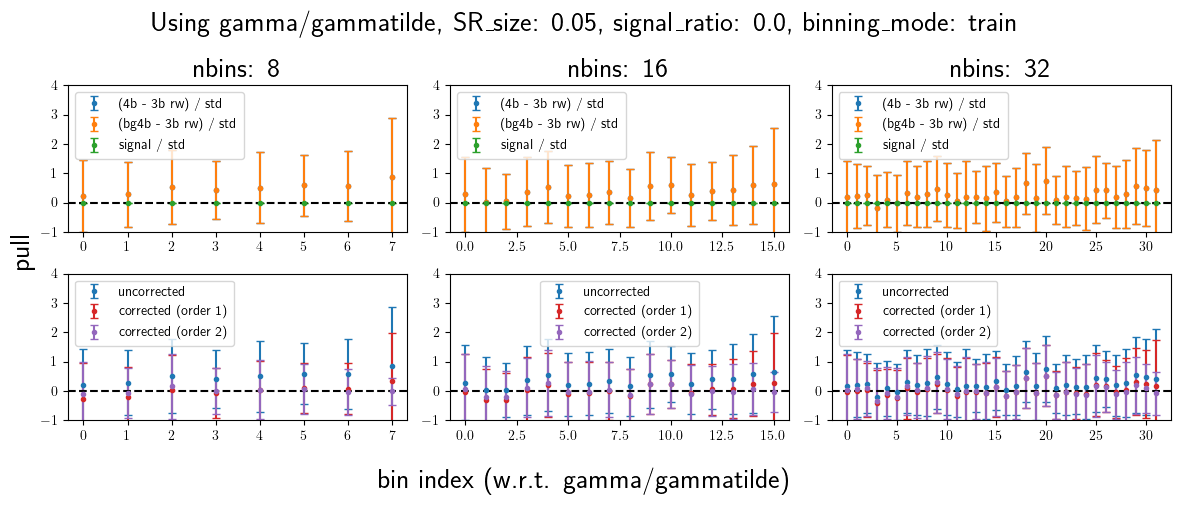

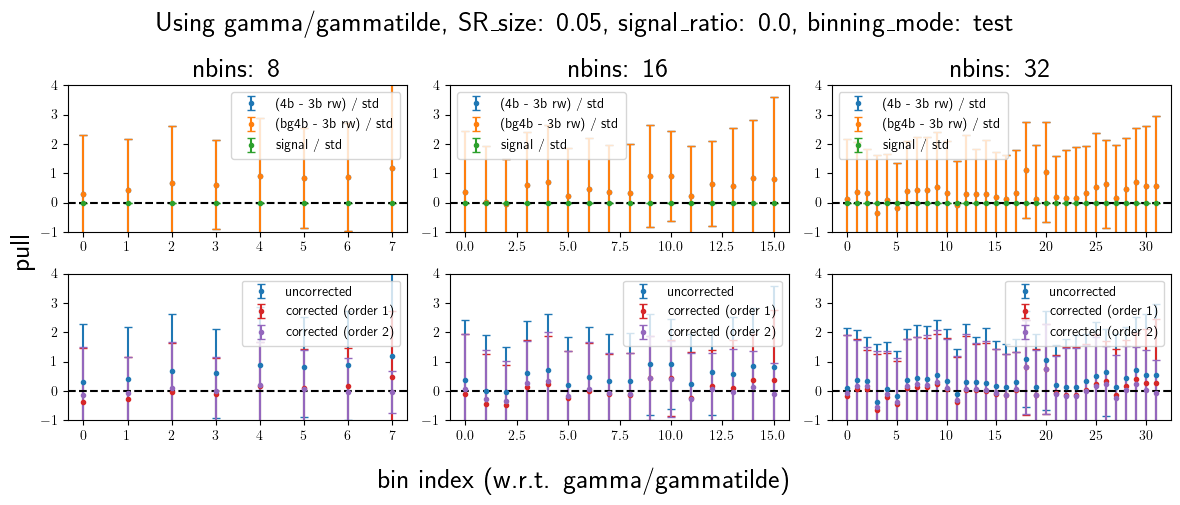

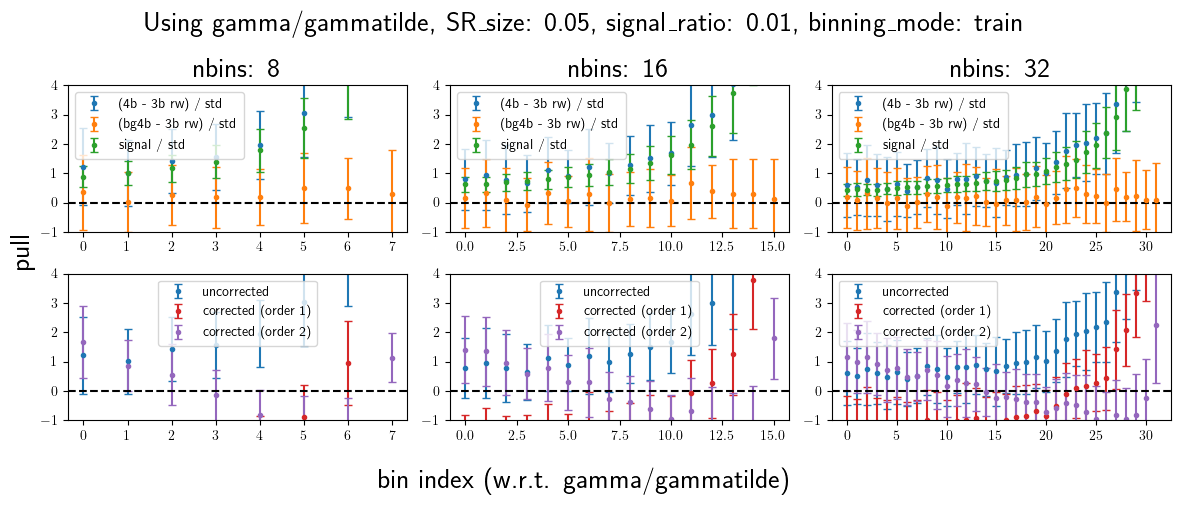

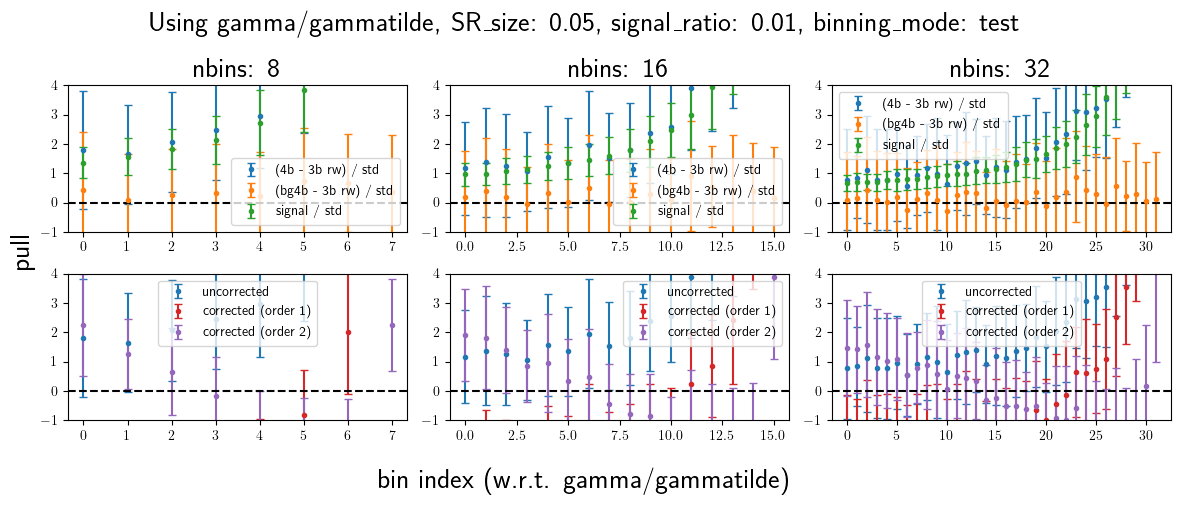

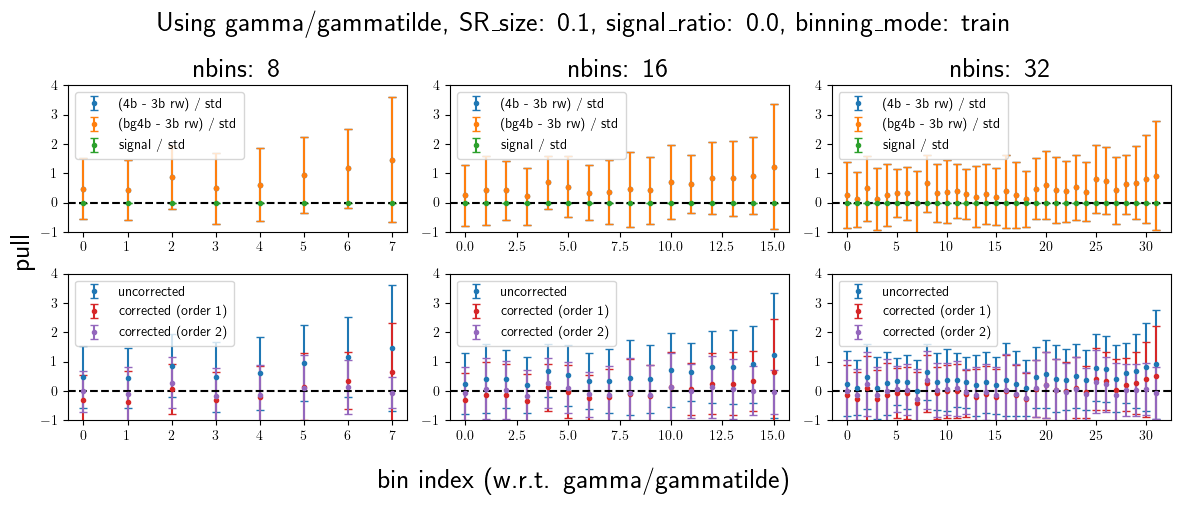

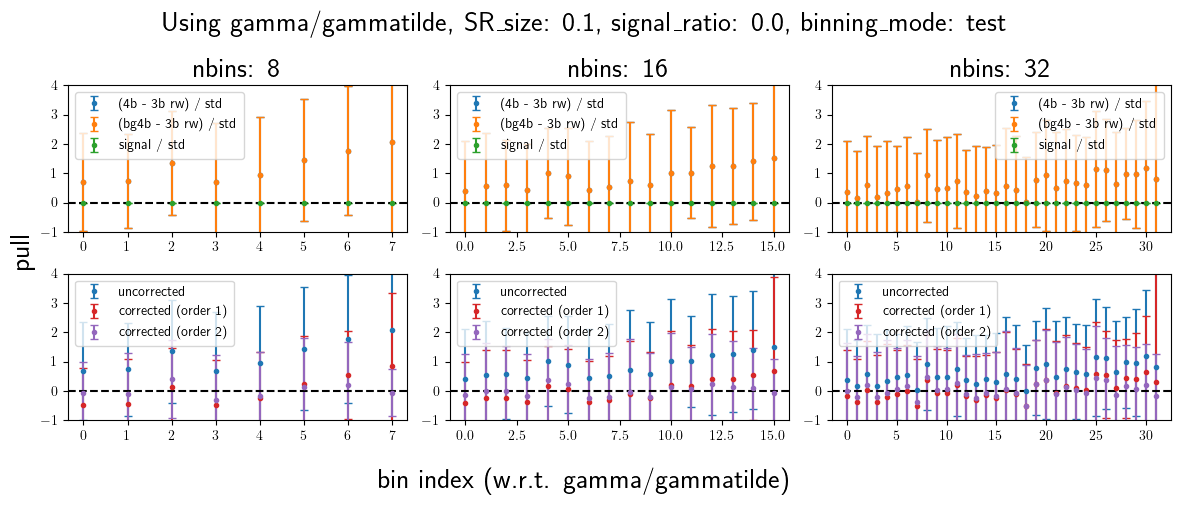

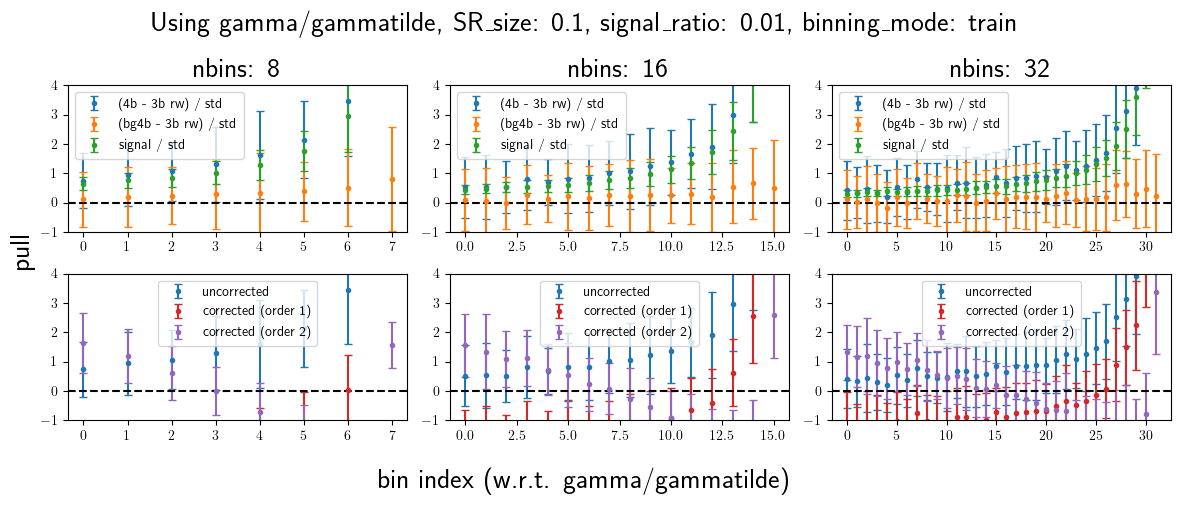

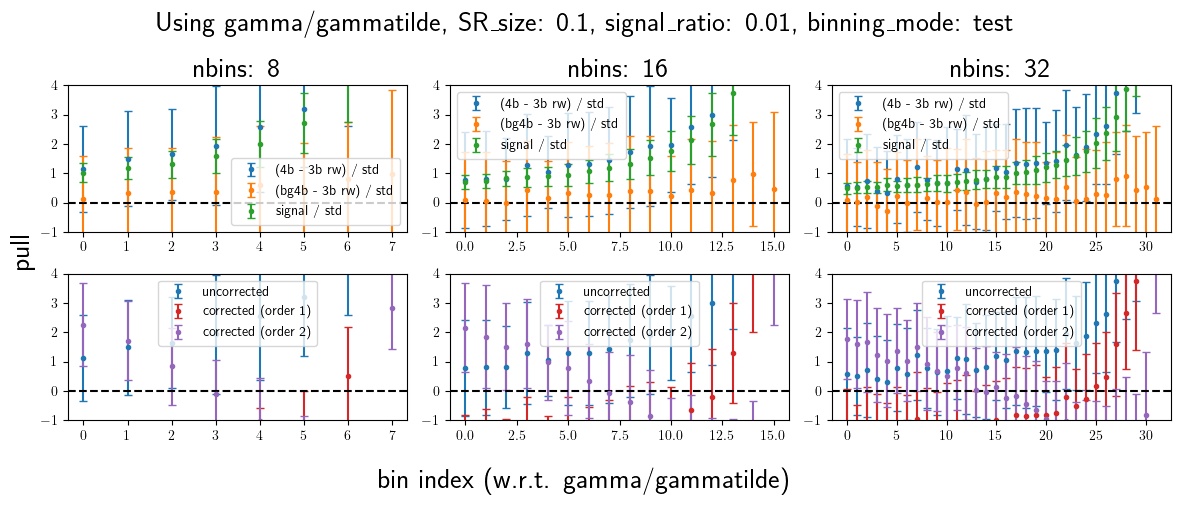

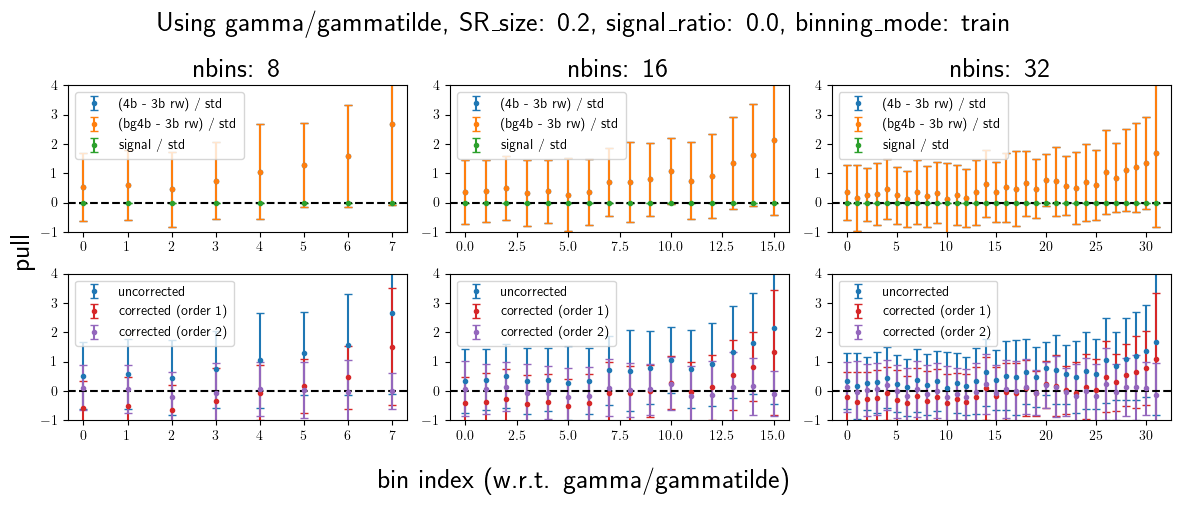

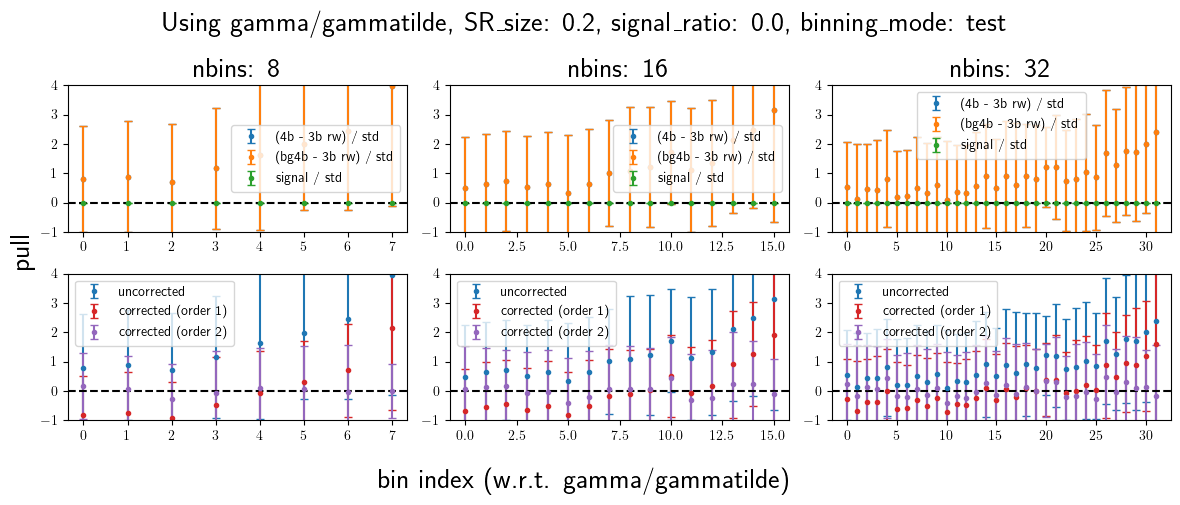

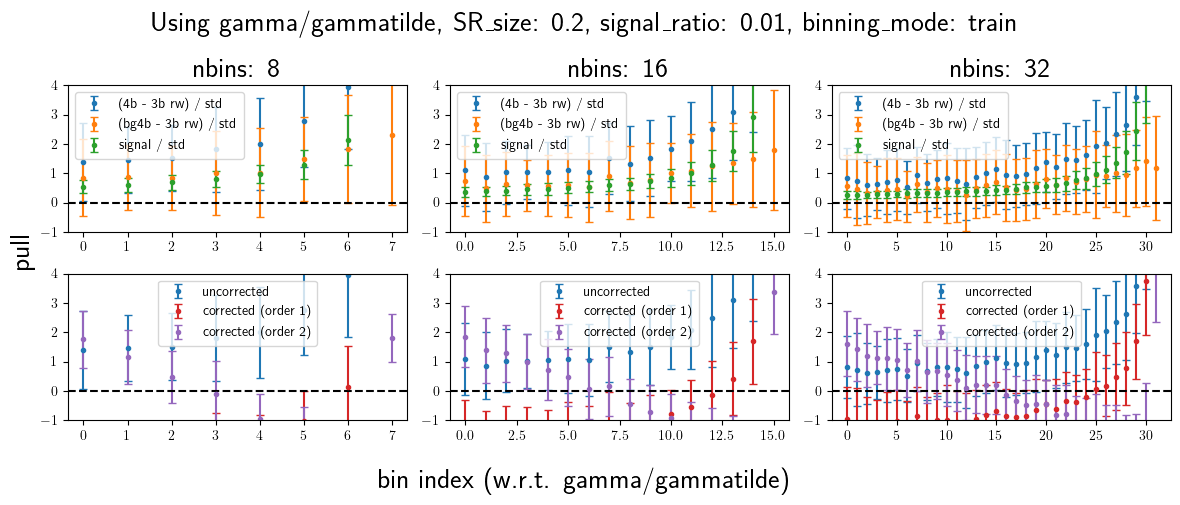

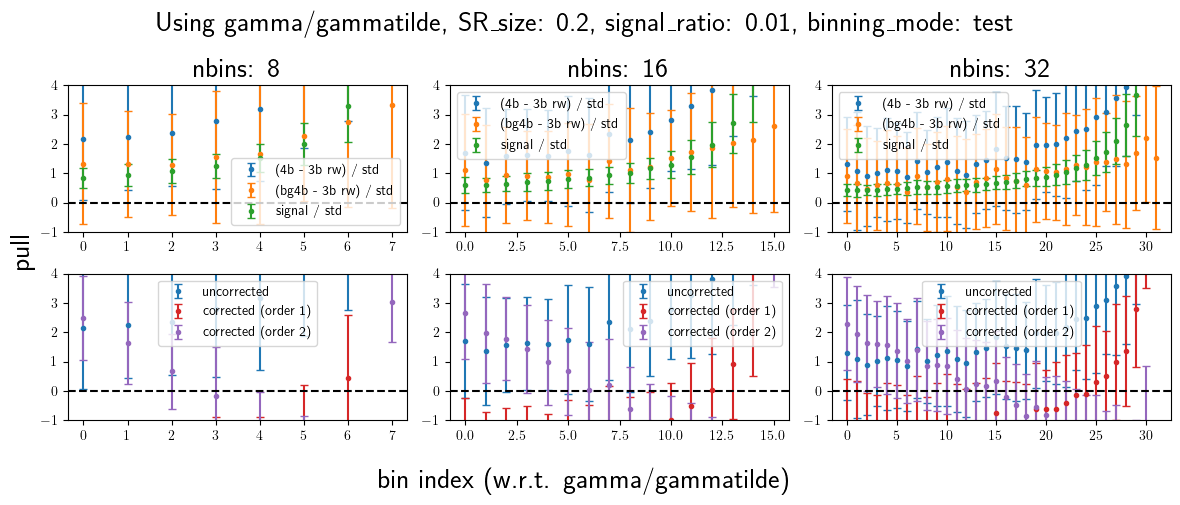

In [ ]:
nbins_list = [8, 16, 32]
pull_dict_as_list = []
for d in sr_stats_pull_dict.values():
    pull_dict_as_list.extend(d)
    
for SR_size in [0.05, 0.1, 0.2]:
    for signal_ratio in [0.0, 0.01]:
        for binning_mode in ["train", "test"]:
            fig, ax = plt.subplots(2, len(nbins_list), figsize=(len(nbins_list) * 4, 5))
            fig.suptitle(f"Using gamma/gammatilde, SR_size: {SR_size}, signal_ratio: {signal_ratio}, binning_mode: {binning_mode}")
            fig.supxlabel("bin index (w.r.t. gamma/gammatilde)")
            fig.supylabel("pull")
            tmp_dicts_target = [d for d in pull_dict_as_list if d["SR_size"] == SR_size 
                        and d["signal_ratio"] == signal_ratio
                        and d["binning_mode"] == binning_mode]
            
            for nbins, ax_idx in zip(nbins_list, range(len(nbins_list))):
                tmp_dicts = [d for d in tmp_dicts_target if d["nbins"] == nbins]
                
                pull_signal_mean = np.mean([d["pull_signal"] for d in tmp_dicts], axis=0)
                pull_signal_std = np.std([d["pull_signal"] for d in tmp_dicts], axis=0)
                
                pull_bg4b_mean = np.mean([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                pull_bg4b_std = np.std([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                
                pull_mean = np.mean([d["pull_o0"] for d in tmp_dicts], axis=0)
                pull_std = np.std([d["pull_o0"] for d in tmp_dicts], axis=0)
                
                pull_mean_corrected_1 = np.mean([d["pull_o1"] for d in tmp_dicts], axis=0)
                pull_std_corrected_1 = np.std([d["pull_o1"] for d in tmp_dicts], axis=0)
                
                pull_mean_corrected_2 = np.mean([d["pull_o2"] for d in tmp_dicts], axis=0)
                pull_std_corrected_2 = np.std([d["pull_o2"] for d in tmp_dicts], axis=0)
                
                
                current_ax_0 = ax[0, ax_idx]
                current_ax_0.set_title(f"nbins: {nbins}")
                bins = np.arange(nbins)
                current_ax_0.errorbar(bins, pull_mean, yerr=pull_std, label="(4b - 3b rw) / std", capsize=3, fmt="o")
                current_ax_0.errorbar(bins, pull_bg4b_mean, yerr=pull_bg4b_std, label="(bg4b - 3b rw) / std", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[1])
                current_ax_0.errorbar(bins, pull_signal_mean, yerr=pull_signal_std, label="signal / std", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[2])
                current_ax_0.axhline(0, color="black", linestyle="--")
                current_ax_0.legend()
                current_ax_0.set_ylim(-1, 4)
                
                current_ax_1 = ax[1, ax_idx]
                current_ax_1.errorbar(bins, pull_mean, yerr=pull_std, label="uncorrected", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[0])
                current_ax_1.errorbar(bins, pull_mean_corrected_1, yerr=pull_std_corrected_1, label="corrected (order 1)", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[3])
                current_ax_1.errorbar(bins, pull_mean_corrected_2, yerr=pull_std_corrected_2, label="corrected (order 2)", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[4])
                current_ax_1.axhline(0, color="black", linestyle="--")
                current_ax_1.legend()
                current_ax_1.set_ylim(-1, 4)
                
            plt.tight_layout()
            plt.show()
            
        colors = plt.get_cmap("tab10").colors

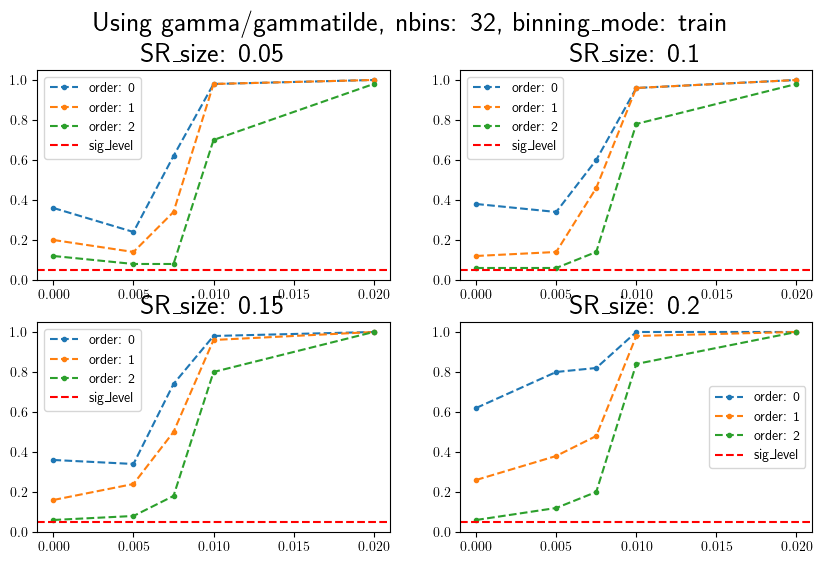

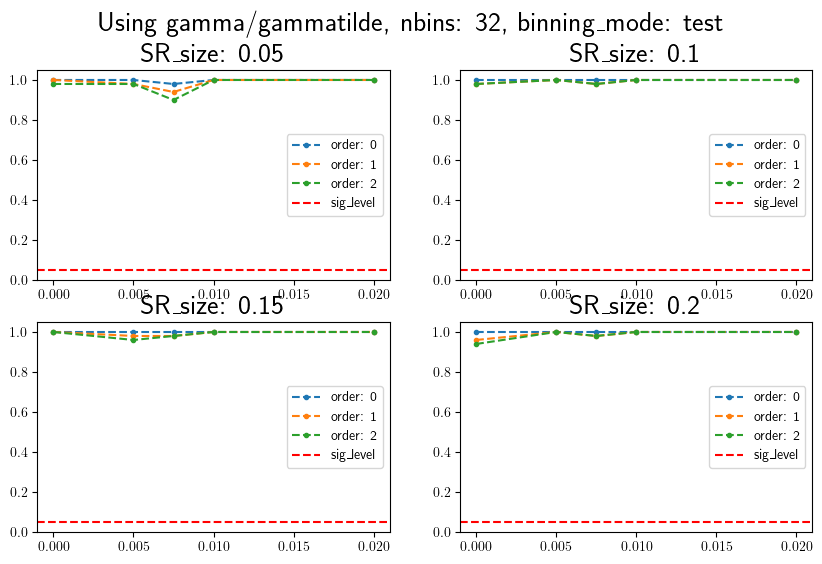

In [17]:
pull_df = pd.DataFrame([
    {"mean_pull_o0": np.sqrt(np.mean(v["pull_o0"]**2)), 
     "mean_pull_o1": np.sqrt(np.mean(v["pull_o1"]**2)), 
     "mean_pull_o2": np.sqrt(np.mean(v["pull_o2"]**2)), 
     "binning_mode": v["binning_mode"],
     "nbins": v["nbins"], 
     "SR_size": v["SR_size"], 
     "signal_ratio": v["signal_ratio"]} for v in pull_dict_as_list])

from scipy.stats import chi2
sig_level = 0.05
pull_df["rej_o0"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"]) / pull_df["nbins"])**0.5
pull_df["rej_o1"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 1) / pull_df["nbins"])**0.5
pull_df["rej_o2"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 2) / pull_df["nbins"])**0.5
pull_df["rejected_o0"] = pull_df["mean_pull_o0"] > pull_df["rej_o0"]
pull_df["rejected_o1"] = pull_df["mean_pull_o1"] > pull_df["rej_o1"]
pull_df["rejected_o2"] = pull_df["mean_pull_o2"] > pull_df["rej_o2"]
pull_df_summary = pull_df.groupby(["SR_size", "signal_ratio", "nbins", "binning_mode"]).mean().reset_index()


nbins = 32

for binning_mode in ["train", "test"]:
    fig, ax = plt.subplots(2, 2, figsize=(10, 6))
    fig.suptitle(f"Using gamma/gammatilde, nbins: {nbins}, binning_mode: {binning_mode}")
    colors = plt.get_cmap("tab10").colors

    for ax_idx, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
        current_ax = ax[ax_idx // 2, ax_idx % 2]
        current_ax.set_title(f"SR_size: {SR_size}")

        pull_df_nbins = pull_df_summary[(pull_df_summary["SR_size"] == SR_size) 
                                        & (pull_df_summary["nbins"] == nbins)
                                        & (pull_df_summary["binning_mode"] == binning_mode)]
        for i, (col, label) in enumerate([("rejected_o0", "order: 0"), 
                        ("rejected_o1", "order: 1"), 
                        ("rejected_o2", "order: 2")]):
            current_ax.plot(pull_df_nbins["signal_ratio"], 
                        pull_df_nbins[col], 
                        label=label, 
                        color=colors[i],
                        linestyle="--",
                        marker="o")
            i += 1
        current_ax.axhline(y=sig_level, color="red", linestyle="--", label="sig_level")
        current_ax.set_ylim(0, 1.05)
        current_ax.legend()
    plt.show()

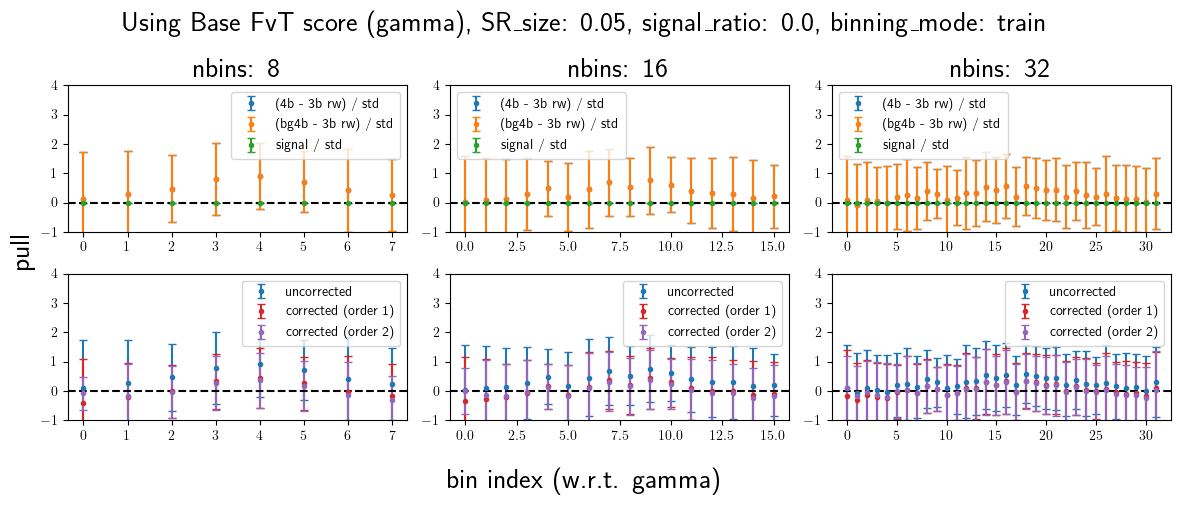

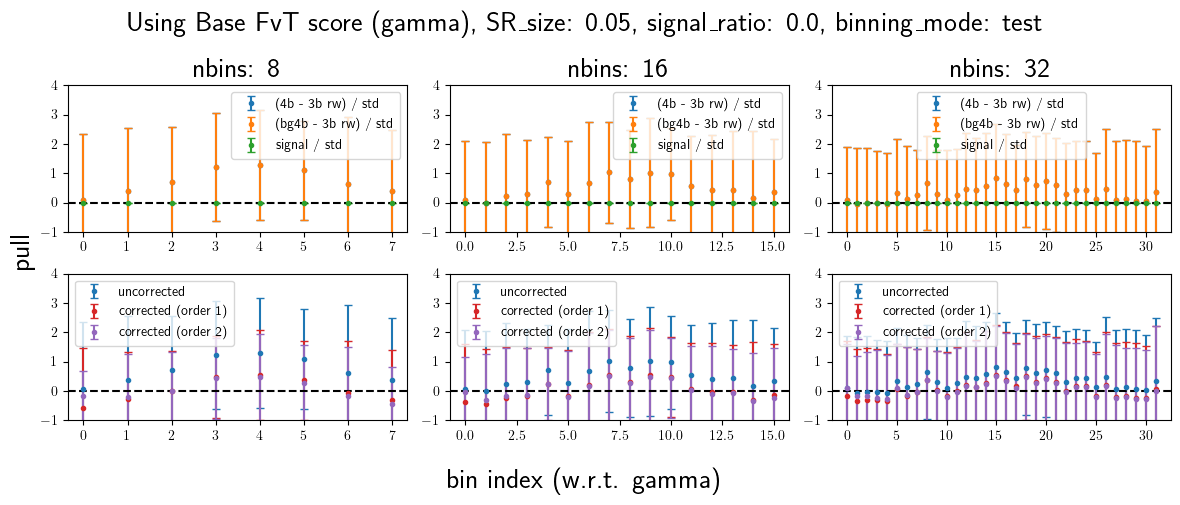

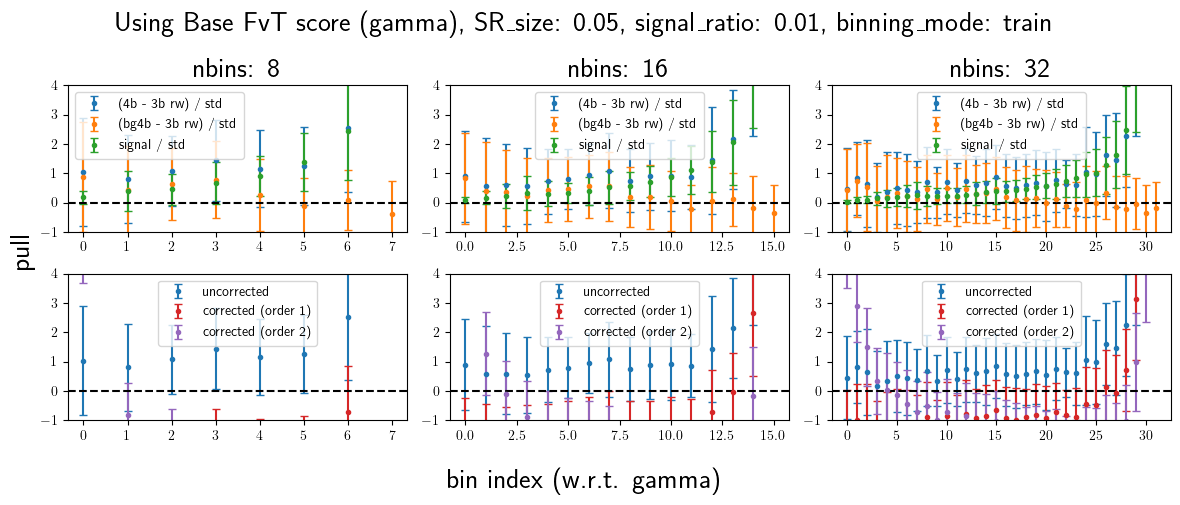

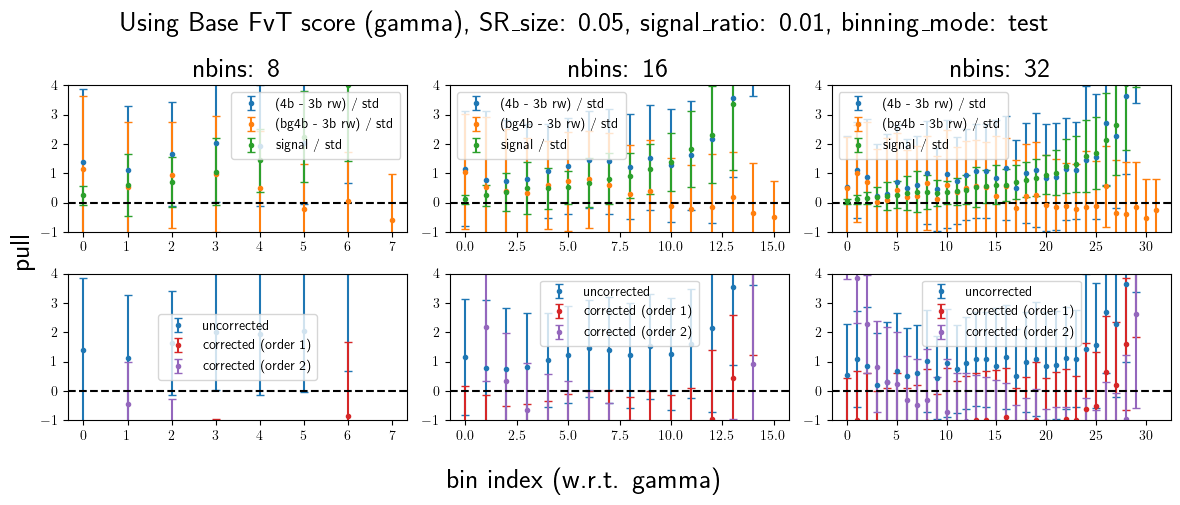

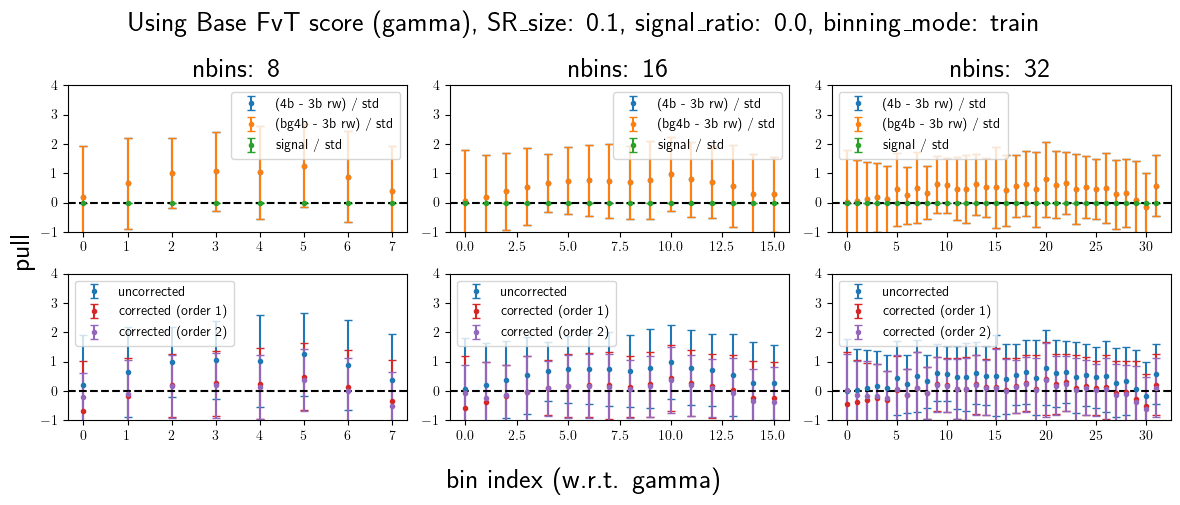

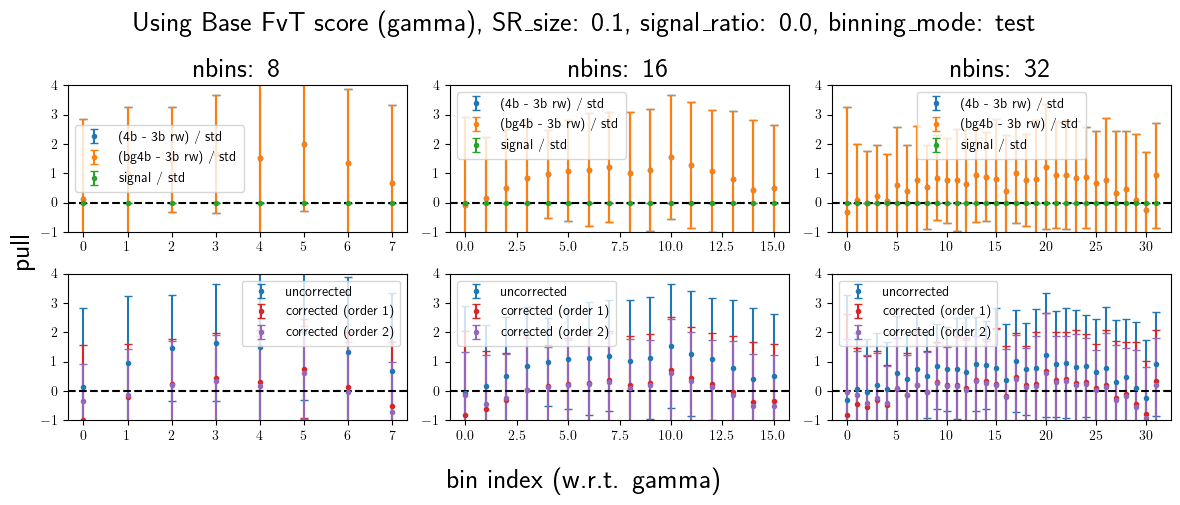

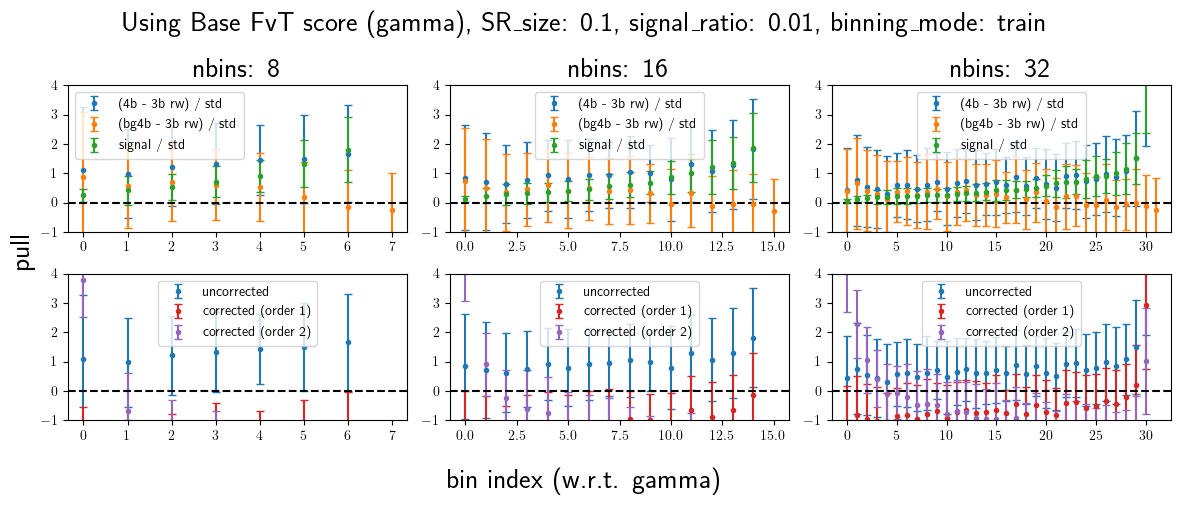

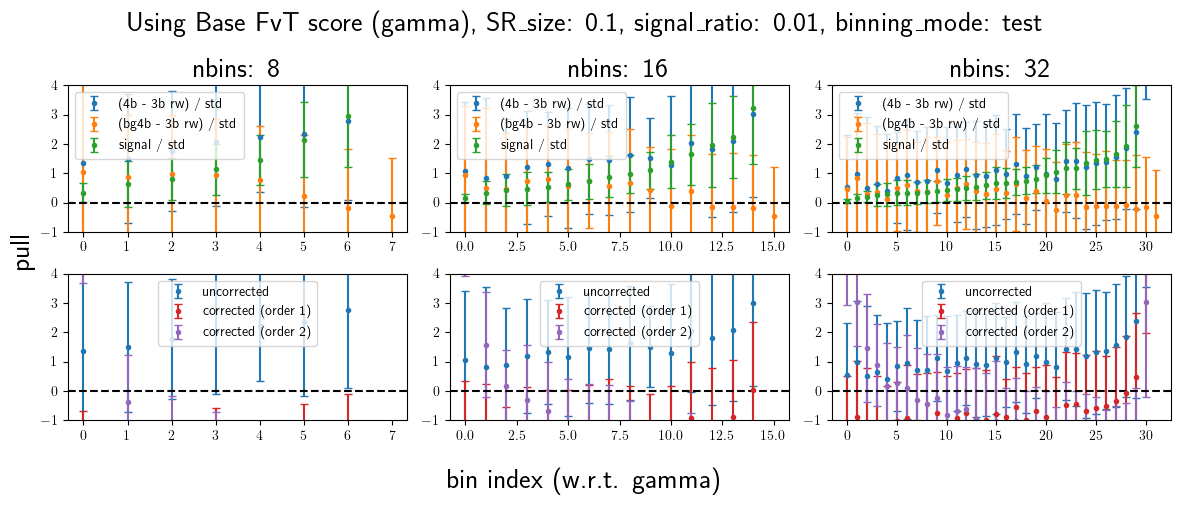

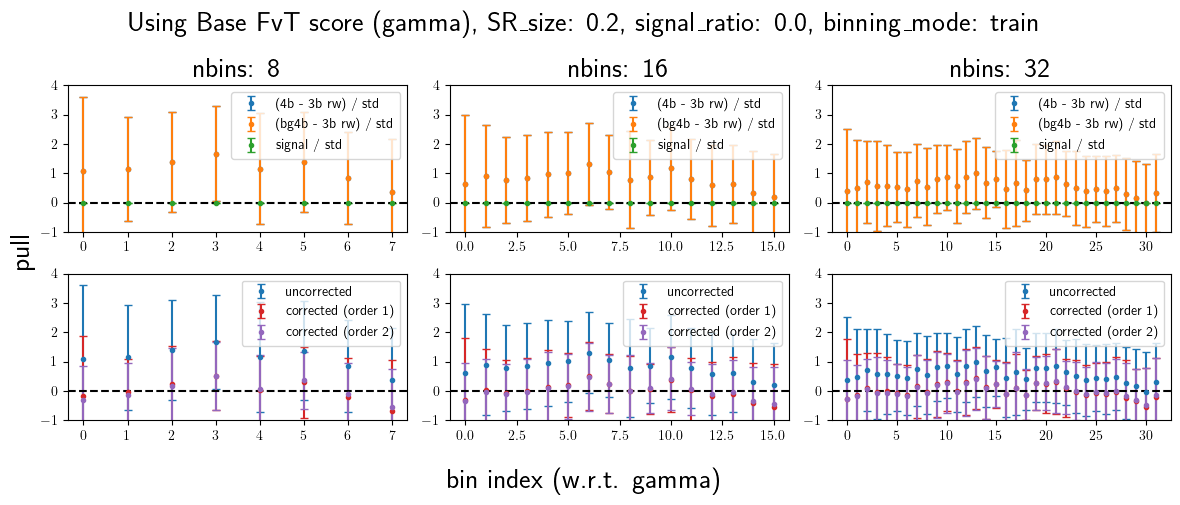

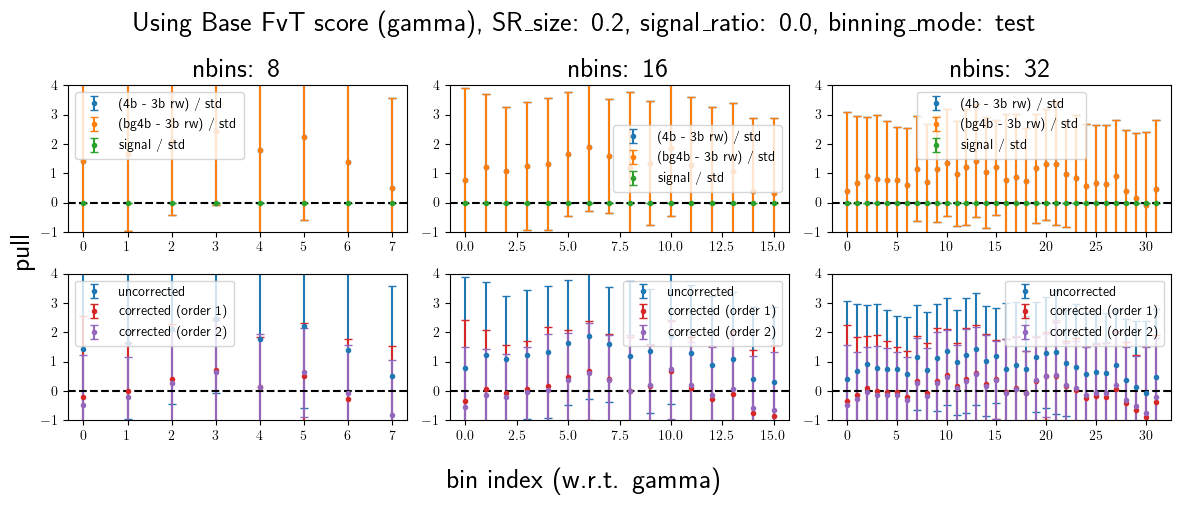

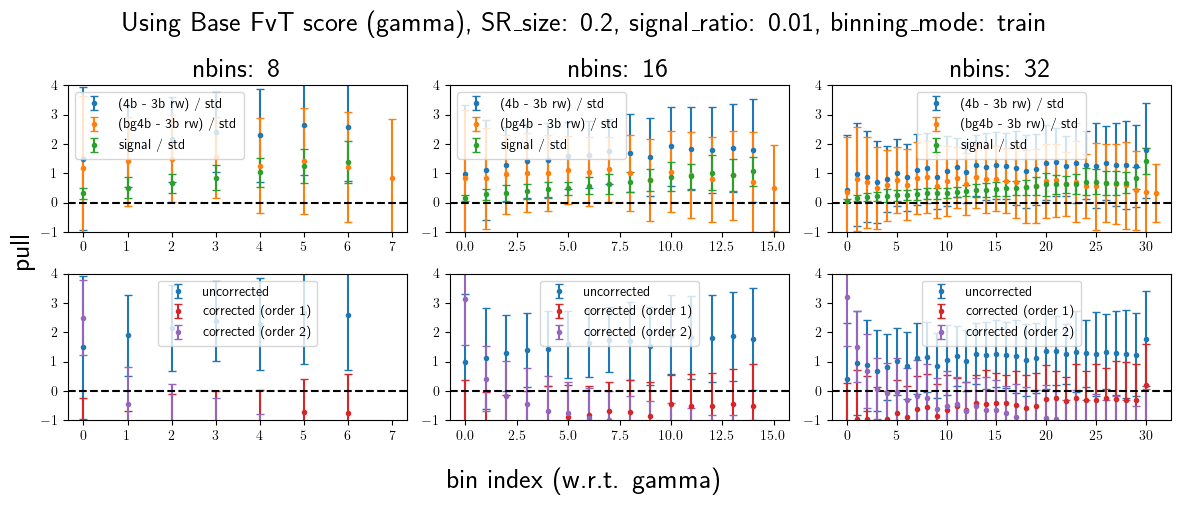

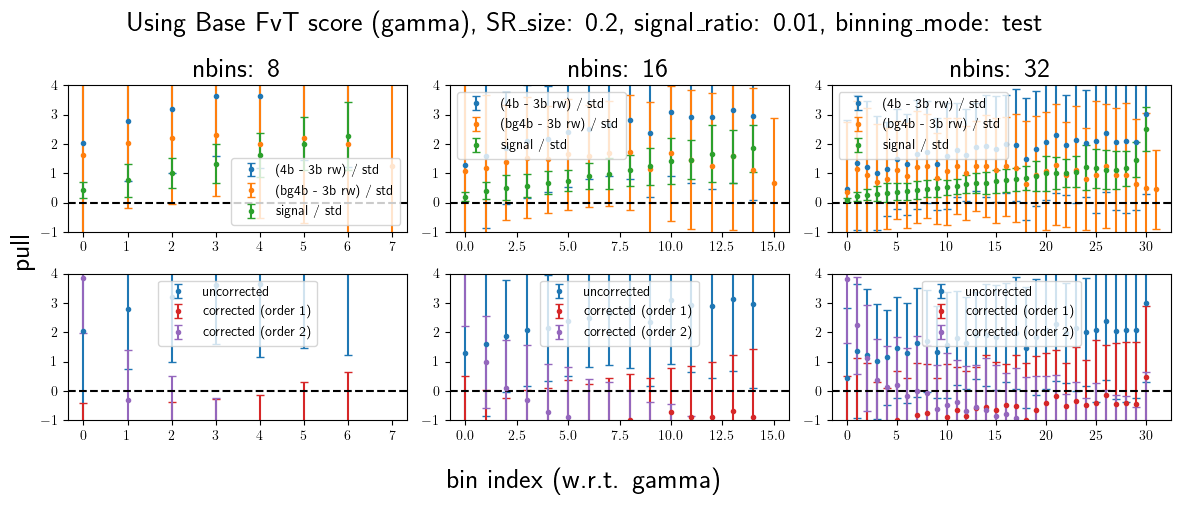

In [18]:
nbins_list = [8, 16, 32]
pull_dict_as_list = []
for d in fvt_pull_dict.values():
    pull_dict_as_list.extend(d)
    
for SR_size in [0.05, 0.1, 0.2]:
    for signal_ratio in [0.0, 0.01]:
        for binning_mode in ["train", "test"]:
            fig, ax = plt.subplots(2, len(nbins_list), figsize=(len(nbins_list) * 4, 5))
            fig.suptitle(f"Using Base FvT score (gamma), SR_size: {SR_size}, signal_ratio: {signal_ratio}, binning_mode: {binning_mode}")
            fig.supxlabel("bin index (w.r.t. gamma)")
            fig.supylabel("pull")
            tmp_dicts_target = [d for d in pull_dict_as_list if d["SR_size"] == SR_size 
                        and d["signal_ratio"] == signal_ratio
                        and d["binning_mode"] == binning_mode]
            
            for nbins, ax_idx in zip(nbins_list, range(len(nbins_list))):
                tmp_dicts = [d for d in tmp_dicts_target if d["nbins"] == nbins]
                
                pull_signal_mean = np.mean([d["pull_signal"] for d in tmp_dicts], axis=0)
                pull_signal_std = np.std([d["pull_signal"] for d in tmp_dicts], axis=0)
                
                pull_bg4b_mean = np.mean([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                pull_bg4b_std = np.std([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                
                pull_mean = np.mean([d["pull_o0"] for d in tmp_dicts], axis=0)
                pull_std = np.std([d["pull_o0"] for d in tmp_dicts], axis=0)
                
                pull_mean_corrected_1 = np.mean([d["pull_o1"] for d in tmp_dicts], axis=0)
                pull_std_corrected_1 = np.std([d["pull_o1"] for d in tmp_dicts], axis=0)
                
                pull_mean_corrected_2 = np.mean([d["pull_o2"] for d in tmp_dicts], axis=0)
                pull_std_corrected_2 = np.std([d["pull_o2"] for d in tmp_dicts], axis=0)
                
                
                current_ax_0 = ax[0, ax_idx]
                current_ax_0.set_title(f"nbins: {nbins}")
                bins = np.arange(nbins)
                current_ax_0.errorbar(bins, pull_mean, yerr=pull_std, label="(4b - 3b rw) / std", capsize=3, fmt="o")
                current_ax_0.errorbar(bins, pull_bg4b_mean, yerr=pull_bg4b_std, label="(bg4b - 3b rw) / std", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[1])
                current_ax_0.errorbar(bins, pull_signal_mean, yerr=pull_signal_std, label="signal / std", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[2])
                current_ax_0.axhline(0, color="black", linestyle="--")
                current_ax_0.legend()
                current_ax_0.set_ylim(-1, 4)
                
                current_ax_1 = ax[1, ax_idx]
                current_ax_1.errorbar(bins, pull_mean, yerr=pull_std, label="uncorrected", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[0])
                current_ax_1.errorbar(bins, pull_mean_corrected_1, yerr=pull_std_corrected_1, label="corrected (order 1)", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[3])
                current_ax_1.errorbar(bins, pull_mean_corrected_2, yerr=pull_std_corrected_2, label="corrected (order 2)", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[4])
                current_ax_1.axhline(0, color="black", linestyle="--")
                current_ax_1.legend()
                current_ax_1.set_ylim(-1, 4)
                
            plt.tight_layout()
            plt.show()
            
        colors = plt.get_cmap("tab10").colors

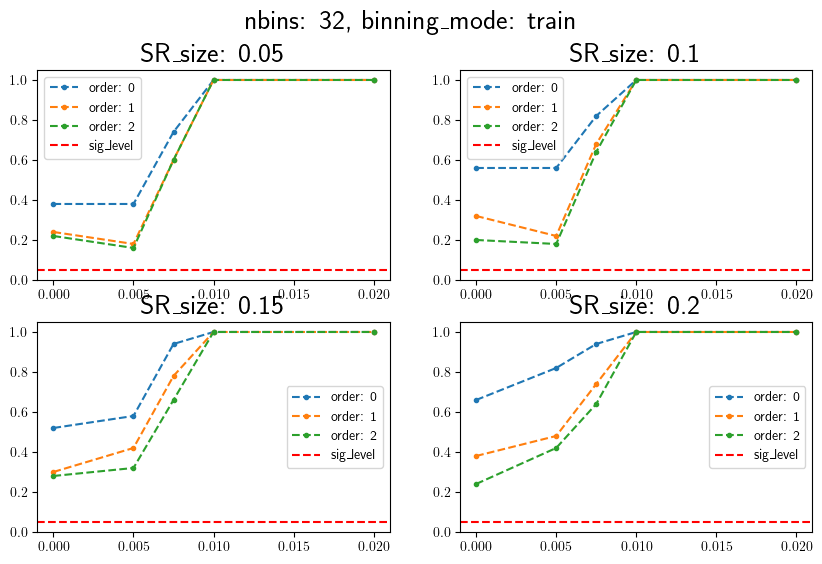

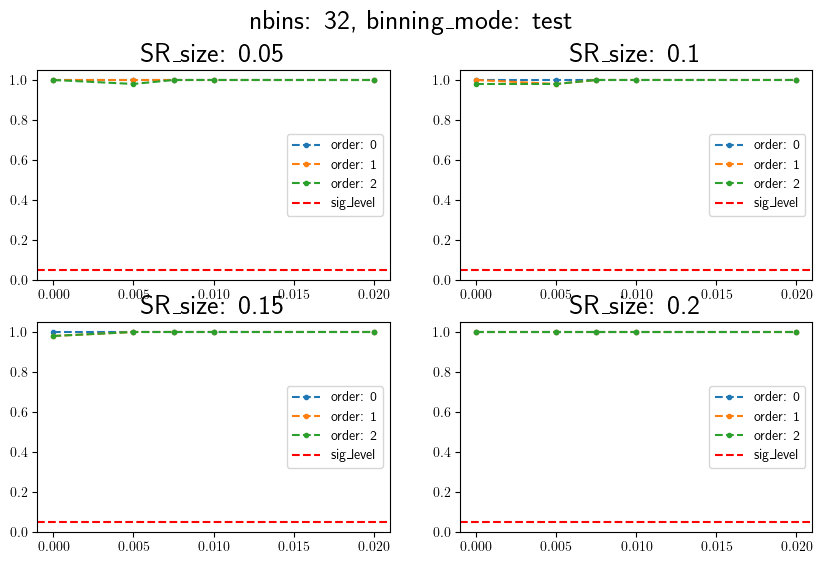

In [19]:
pull_df = pd.DataFrame([
    {"mean_pull_o0": np.sqrt(np.mean(v["pull_o0"]**2)), 
     "mean_pull_o1": np.sqrt(np.mean(v["pull_o1"]**2)), 
     "mean_pull_o2": np.sqrt(np.mean(v["pull_o2"]**2)), 
     "binning_mode": v["binning_mode"],
     "nbins": v["nbins"], 
     "SR_size": v["SR_size"], 
     "signal_ratio": v["signal_ratio"]} for v in pull_dict_as_list])

from scipy.stats import chi2
sig_level = 0.05
pull_df["rej_o0"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"]) / pull_df["nbins"])**0.5
pull_df["rej_o1"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 1) / pull_df["nbins"])**0.5
pull_df["rej_o2"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 2) / pull_df["nbins"])**0.5
pull_df["rejected_o0"] = pull_df["mean_pull_o0"] > pull_df["rej_o0"]
pull_df["rejected_o1"] = pull_df["mean_pull_o1"] > pull_df["rej_o1"]
pull_df["rejected_o2"] = pull_df["mean_pull_o2"] > pull_df["rej_o2"]
pull_df_summary = pull_df.groupby(["SR_size", "signal_ratio", "nbins", "binning_mode"]).mean().reset_index()


nbins = 32

for binning_mode in ["train", "test"]:
    fig, ax = plt.subplots(2, 2, figsize=(10, 6))
    fig.suptitle(f"nbins: {nbins}, binning_mode: {binning_mode}")
    colors = plt.get_cmap("tab10").colors

    for ax_idx, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
        current_ax = ax[ax_idx // 2, ax_idx % 2]
        current_ax.set_title(f"SR_size: {SR_size}")

        pull_df_nbins = pull_df_summary[(pull_df_summary["SR_size"] == SR_size) 
                                        & (pull_df_summary["nbins"] == nbins)
                                        & (pull_df_summary["binning_mode"] == binning_mode)]
        for i, (col, label) in enumerate([("rejected_o0", "order: 0"), 
                        ("rejected_o1", "order: 1"), 
                        ("rejected_o2", "order: 2")]):
            current_ax.plot(pull_df_nbins["signal_ratio"], 
                        pull_df_nbins[col], 
                        label=label, 
                        color=colors[i],
                        linestyle="--",
                        marker="o")
            i += 1
        current_ax.axhline(y=sig_level, color="red", linestyle="--", label="sig_level")
        current_ax.set_ylim(0, 1.05)
        current_ax.legend()
    plt.show()

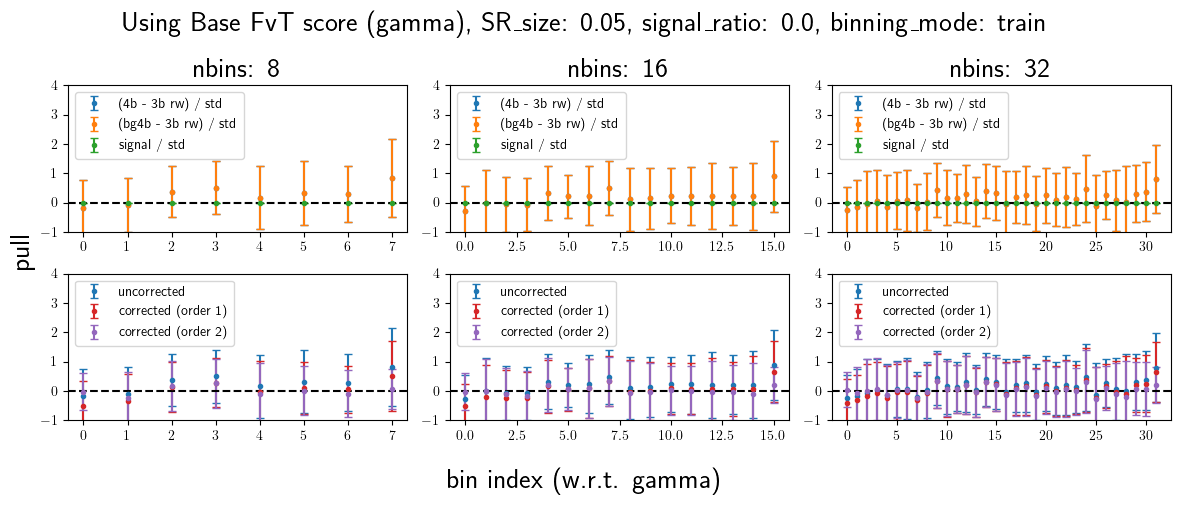

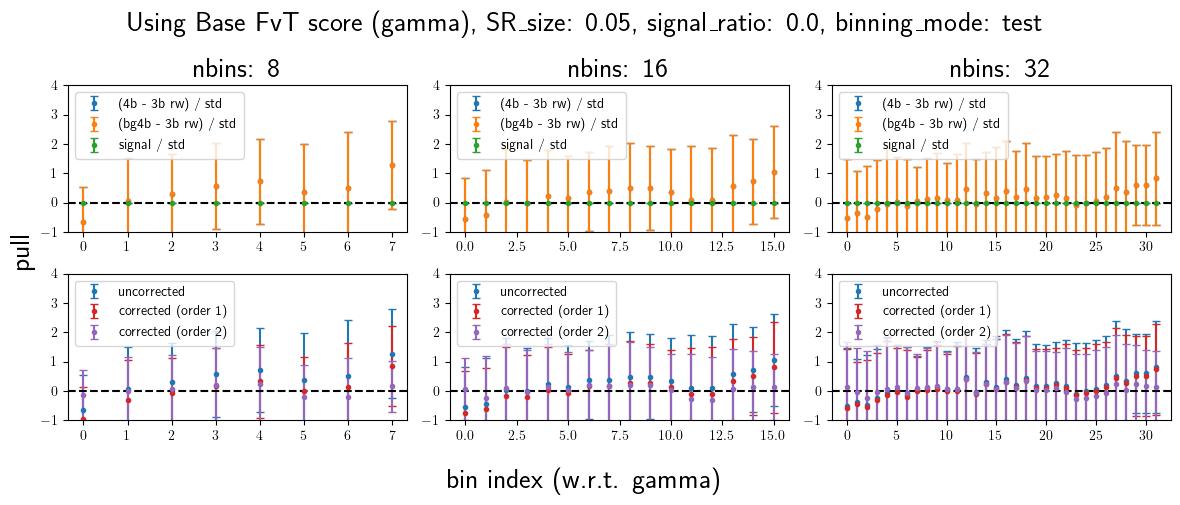

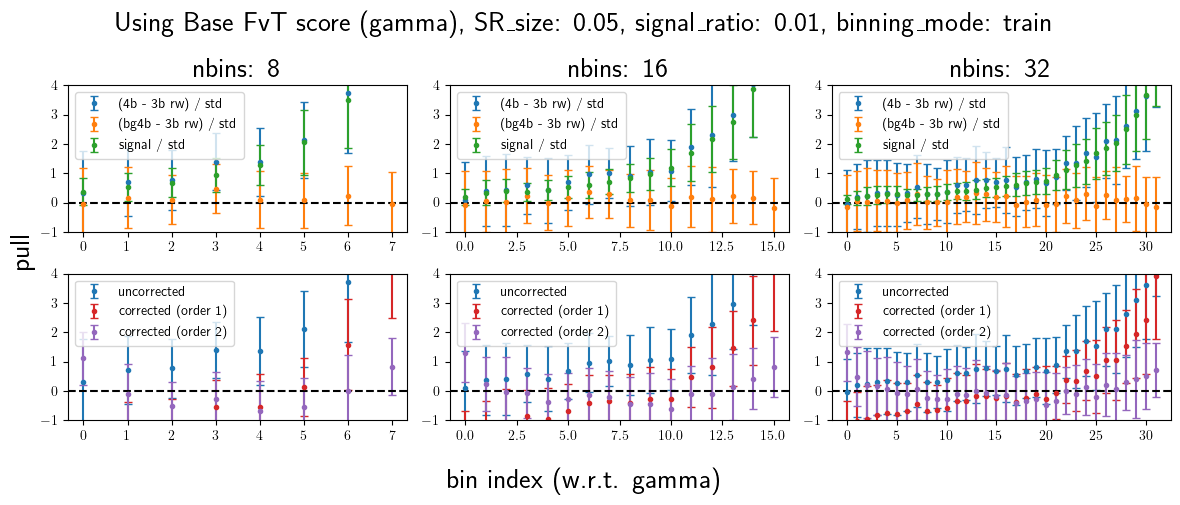

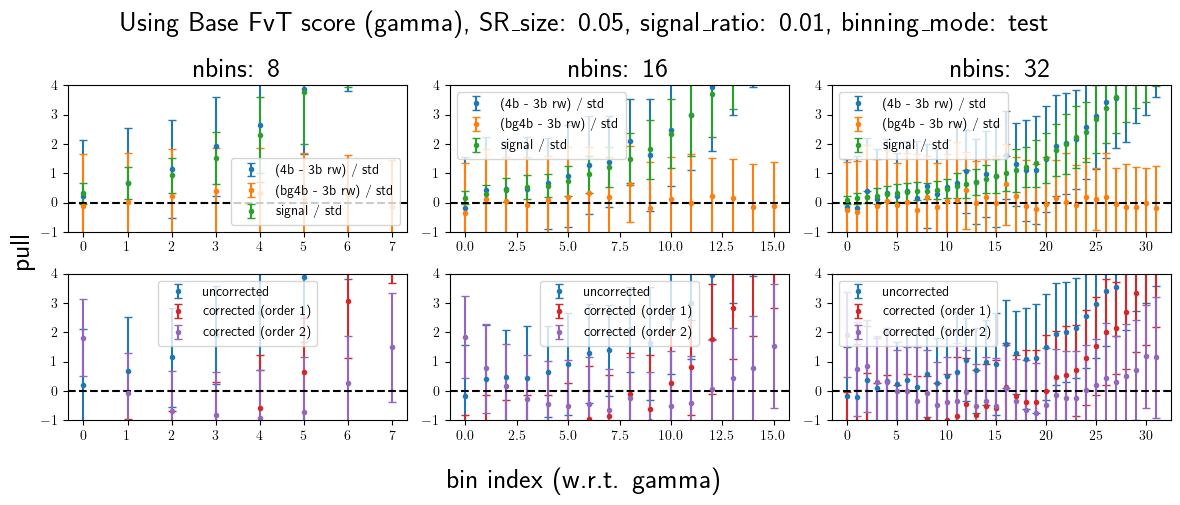

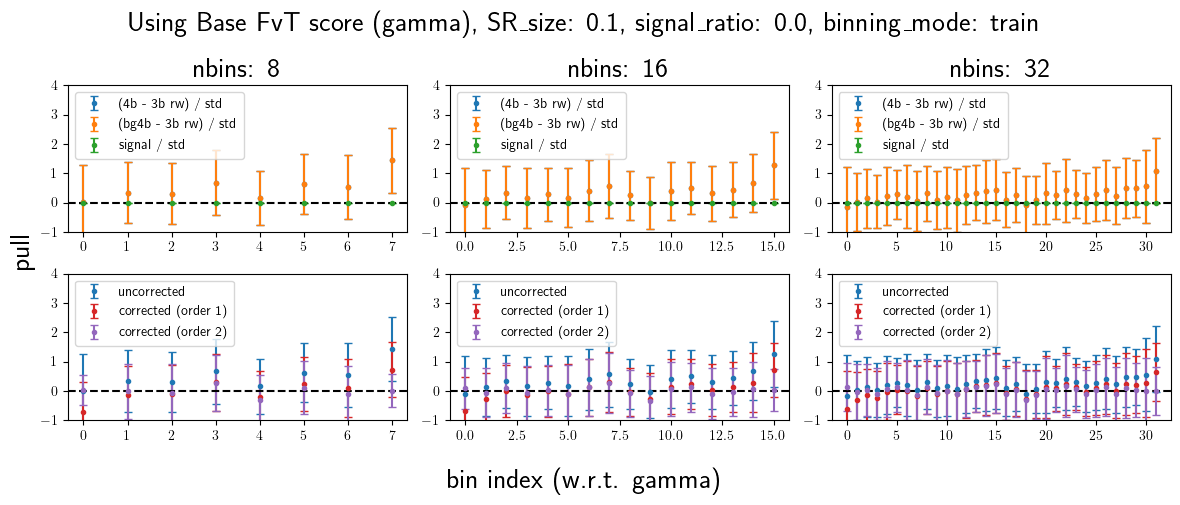

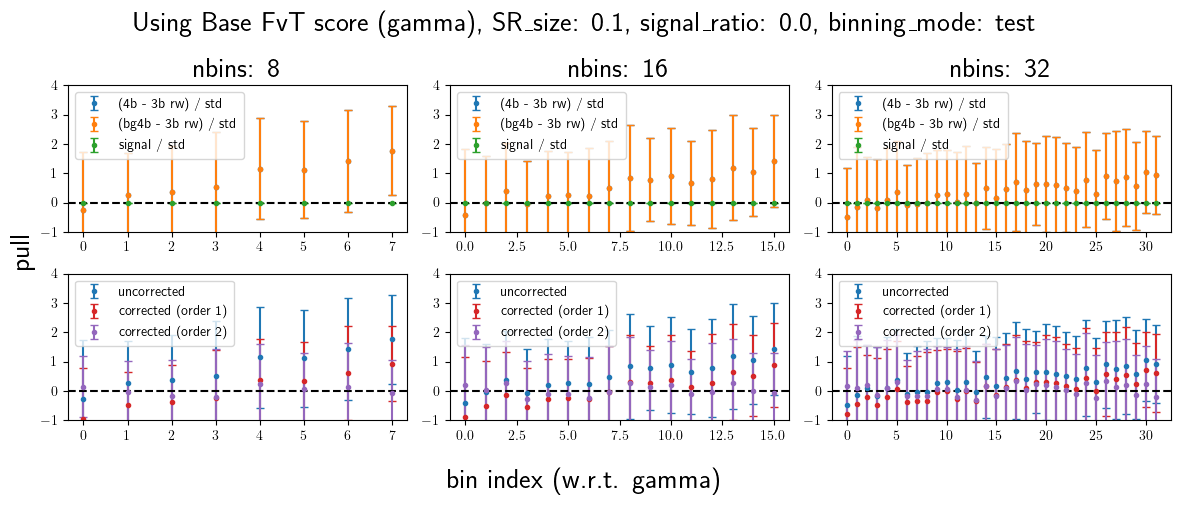

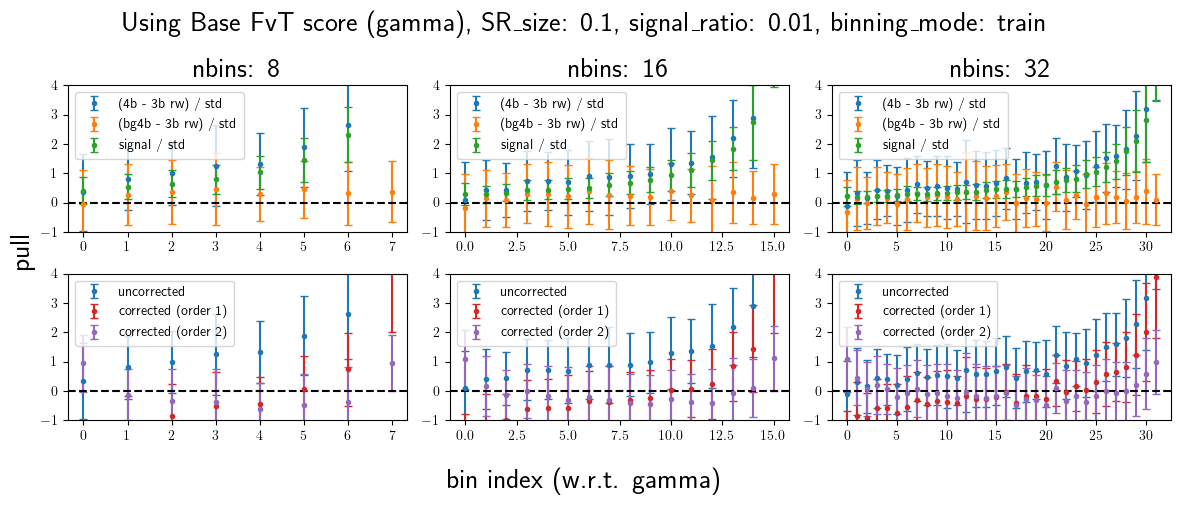

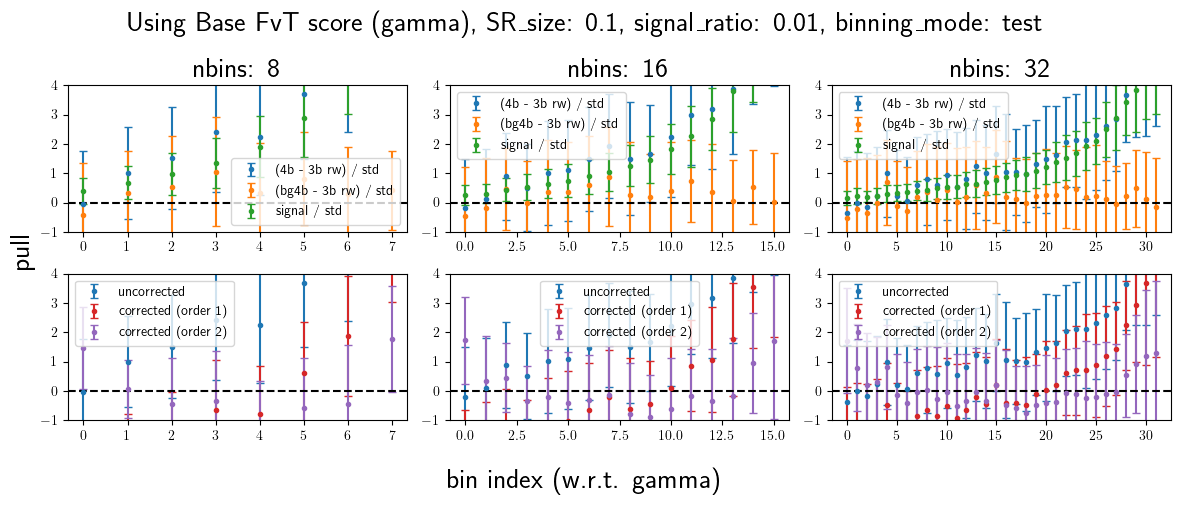

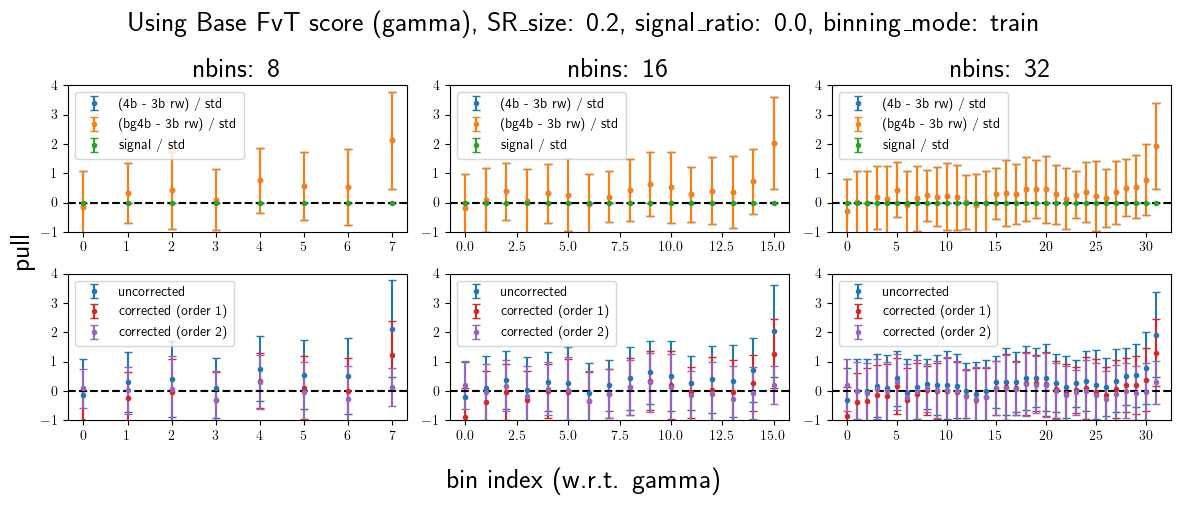

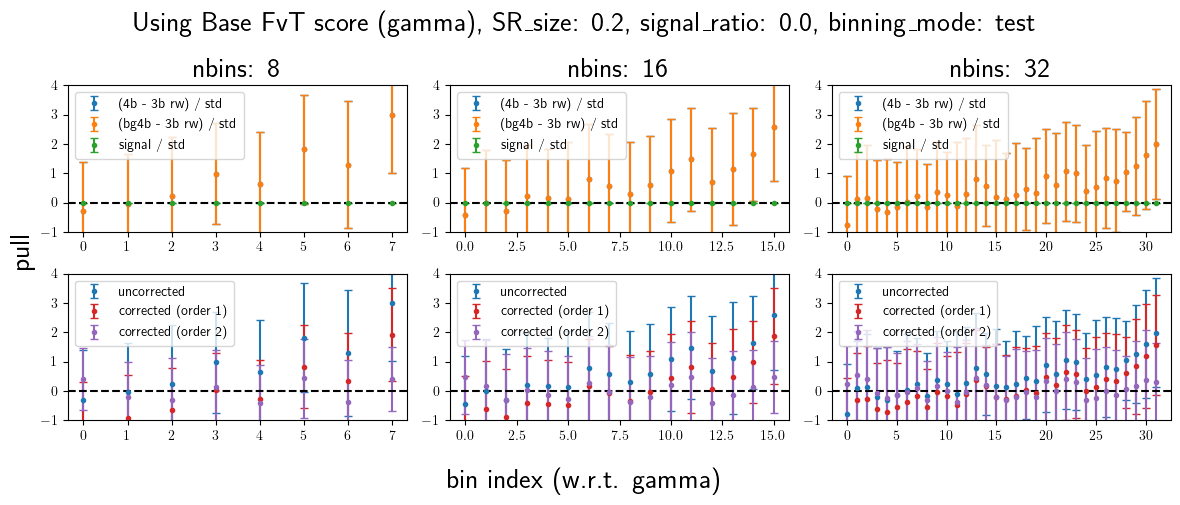

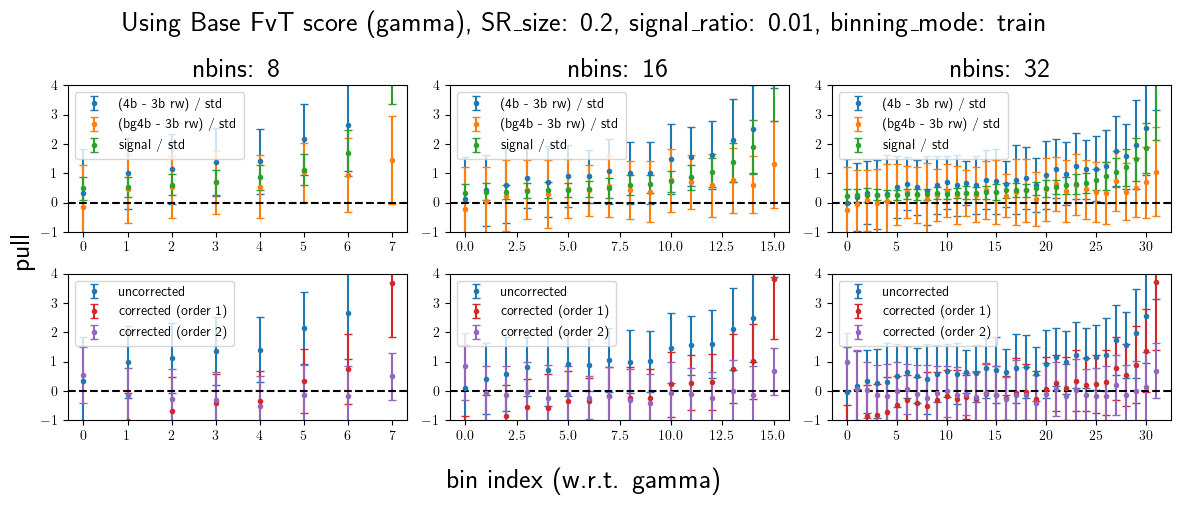

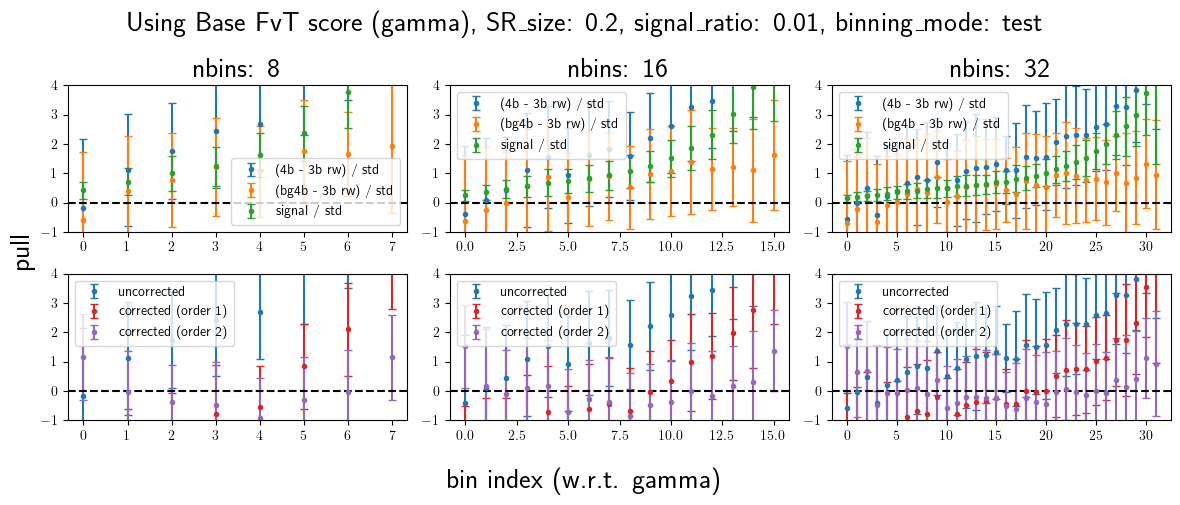

In [20]:
nbins_list = [8, 16, 32]
pull_dict_as_list = []
for d in mi_test_pull_dict.values():
    pull_dict_as_list.extend(d)
    
for SR_size in [0.05, 0.1, 0.2]:
    for signal_ratio in [0.0, 0.01]:
        for binning_mode in ["train", "test"]:
            fig, ax = plt.subplots(2, len(nbins_list), figsize=(len(nbins_list) * 4, 5))
            fig.suptitle(f"Using Base FvT score (gamma), SR_size: {SR_size}, signal_ratio: {signal_ratio}, binning_mode: {binning_mode}")
            fig.supxlabel("bin index (w.r.t. gamma)")
            fig.supylabel("pull")
            tmp_dicts_target = [d for d in pull_dict_as_list if d["SR_size"] == SR_size 
                        and d["signal_ratio"] == signal_ratio
                        and d["binning_mode"] == binning_mode
                        and d["batch_size"] == 1024]
            
            for nbins, ax_idx in zip(nbins_list, range(len(nbins_list))):
                tmp_dicts = [d for d in tmp_dicts_target if d["nbins"] == nbins]
                
                pull_signal_mean = np.mean([d["pull_signal"] for d in tmp_dicts], axis=0)
                pull_signal_std = np.std([d["pull_signal"] for d in tmp_dicts], axis=0)
                
                pull_bg4b_mean = np.mean([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                pull_bg4b_std = np.std([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                
                pull_mean = np.mean([d["pull_o0"] for d in tmp_dicts], axis=0)
                pull_std = np.std([d["pull_o0"] for d in tmp_dicts], axis=0)
                
                pull_mean_corrected_1 = np.mean([d["pull_o1"] for d in tmp_dicts], axis=0)
                pull_std_corrected_1 = np.std([d["pull_o1"] for d in tmp_dicts], axis=0)
                
                pull_mean_corrected_2 = np.mean([d["pull_o2"] for d in tmp_dicts], axis=0)
                pull_std_corrected_2 = np.std([d["pull_o2"] for d in tmp_dicts], axis=0)
                
                
                current_ax_0 = ax[0, ax_idx]
                current_ax_0.set_title(f"nbins: {nbins}")
                bins = np.arange(nbins)
                current_ax_0.errorbar(bins, pull_mean, yerr=pull_std, label="(4b - 3b rw) / std", capsize=3, fmt="o")
                current_ax_0.errorbar(bins, pull_bg4b_mean, yerr=pull_bg4b_std, label="(bg4b - 3b rw) / std", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[1])
                current_ax_0.errorbar(bins, pull_signal_mean, yerr=pull_signal_std, label="signal / std", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[2])
                current_ax_0.axhline(0, color="black", linestyle="--")
                current_ax_0.legend()
                current_ax_0.set_ylim(-1, 4)
                
                current_ax_1 = ax[1, ax_idx]
                current_ax_1.errorbar(bins, pull_mean, yerr=pull_std, label="uncorrected", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[0])
                current_ax_1.errorbar(bins, pull_mean_corrected_1, yerr=pull_std_corrected_1, label="corrected (order 1)", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[3])
                current_ax_1.errorbar(bins, pull_mean_corrected_2, yerr=pull_std_corrected_2, label="corrected (order 2)", capsize=3, fmt="o", 
                                    color=plt.get_cmap("tab10").colors[4])
                current_ax_1.axhline(0, color="black", linestyle="--")
                current_ax_1.legend()
                current_ax_1.set_ylim(-1, 4)
                
            plt.tight_layout()
            plt.show()
            
        colors = plt.get_cmap("tab10").colors

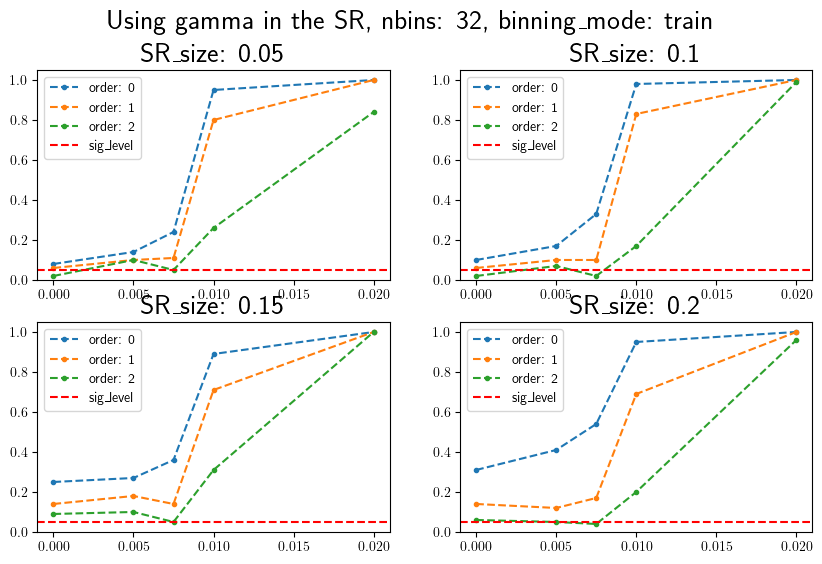

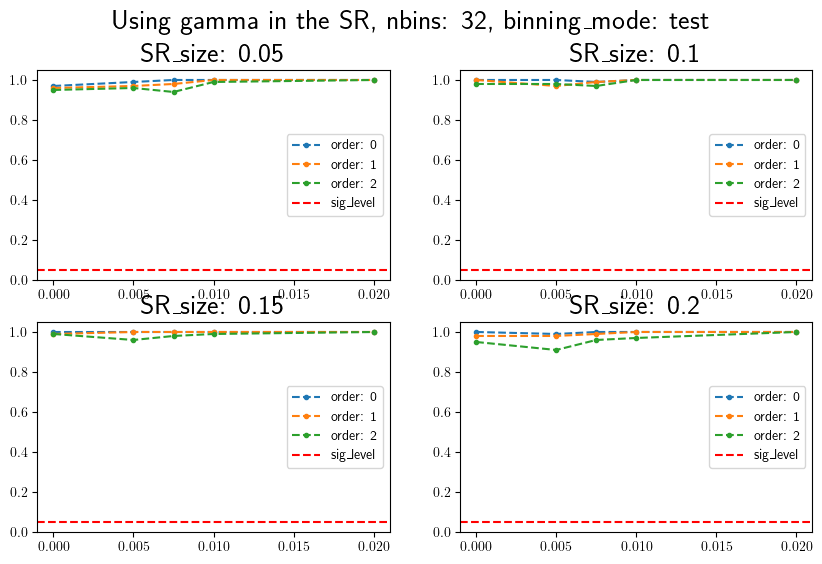

In [21]:
pull_df = pd.DataFrame([
    {"mean_pull_o0": np.sqrt(np.mean(v["pull_o0"]**2)), 
     "mean_pull_o1": np.sqrt(np.mean(v["pull_o1"]**2)), 
     "mean_pull_o2": np.sqrt(np.mean(v["pull_o2"]**2)), 
     "binning_mode": v["binning_mode"],
     "nbins": v["nbins"], 
     "SR_size": v["SR_size"], 
     "signal_ratio": v["signal_ratio"]} for v in pull_dict_as_list])

from scipy.stats import chi2
sig_level = 0.05
pull_df["rej_o0"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"]) / pull_df["nbins"])**0.5
pull_df["rej_o1"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 1) / pull_df["nbins"])**0.5
pull_df["rej_o2"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 2) / pull_df["nbins"])**0.5
pull_df["rejected_o0"] = pull_df["mean_pull_o0"] > pull_df["rej_o0"]
pull_df["rejected_o1"] = pull_df["mean_pull_o1"] > pull_df["rej_o1"]
pull_df["rejected_o2"] = pull_df["mean_pull_o2"] > pull_df["rej_o2"]
pull_df_summary = pull_df.groupby(["SR_size", "signal_ratio", "nbins", "binning_mode"]).mean().reset_index()


nbins = 32

for binning_mode in ["train", "test"]:
    fig, ax = plt.subplots(2, 2, figsize=(10, 6))
    fig.suptitle(f"Using gamma in the SR, nbins: {nbins}, binning_mode: {binning_mode}")
    colors = plt.get_cmap("tab10").colors

    for ax_idx, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
        current_ax = ax[ax_idx // 2, ax_idx % 2]
        current_ax.set_title(f"SR_size: {SR_size}")

        pull_df_nbins = pull_df_summary[(pull_df_summary["SR_size"] == SR_size) 
                                        & (pull_df_summary["nbins"] == nbins)
                                        & (pull_df_summary["binning_mode"] == binning_mode)]
        for i, (col, label) in enumerate([("rejected_o0", "order: 0"), 
                        ("rejected_o1", "order: 1"), 
                        ("rejected_o2", "order: 2")]):
            current_ax.plot(pull_df_nbins["signal_ratio"], 
                        pull_df_nbins[col], 
                        label=label, 
                        color=colors[i],
                        linestyle="--",
                        marker="o")
            i += 1
        current_ax.axhline(y=sig_level, color="red", linestyle="--", label="sig_level")
        current_ax.set_ylim(0, 1.05)
        current_ax.legend()
    plt.show()